IMPORT LIABRARIES:

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
from scipy import stats

UPLOAD & READ CSV:

In [13]:
df = pd.read_csv('/content/synthetic_customer_churn_100k.csv')


1. DATA INSPECTION & STRUCTURE:

In [16]:
# 1. View the first 5 rows
print(" FIRST 5 ROWS (head)")
print(df.head())

# 2. View the last 5 rows
print("\n LAST 5 ROWS (tail)")
print(df.tail())

# 3. Check the dimensions of the dataset (Rows, Columns)
print("\nDATASET SHAPE")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# 4. Check data types, non-null counts, and memory usage
print("\nDATA INFO")
df.info()

# 5. List all column names
print("\nCOLUMN NAMES")
print(df.columns.tolist())

# 6. Count unique values in each column
# Useful to distinguish between Categorical and Numerical data
print("\nUNIQUE VALUES PER COLUMN")
print(df.nunique())

 FIRST 5 ROWS (head)
   CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract  \
0           1   56  Female      68          147.58        Two year   
1           2   69    Male      32           22.54  Month-to-month   
2           3   46  Female      10           52.47        One year   
3           4   32    Male      22          109.67  Month-to-month   
4           5   60  Female      54          130.98  Month-to-month   

      PaymentMethod  TotalCharges Churn  
0     Bank transfer      10052.03    No  
1      Mailed check        686.78    No  
2  Electronic check        537.88    No  
3      Mailed check       2390.04   Yes  
4       Credit card       7081.28    No  

 LAST 5 ROWS (tail)
       CustomerID  Age  Gender  Tenure  MonthlyCharges        Contract  \
99995       99996   31    Male      49           26.07  Month-to-month   
99996       99997   64  Female      44          123.22  Month-to-month   
99997       99998   48   Other      32           75.37  Month-t

2. DATA CLEANING & MISSING VALUES:

In [41]:

# 1. CHECK FOR DUPLICATE ROWS
duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")

# 2. Check for missing values
print("Missing Values Count per Column")
missing_count = df.isnull().sum()
print(missing_count)

# 3. Fill missing values (Imputation)
# We check if there's at least one missing value in the entire dataframe
if missing_count.sum() > 0:
    print("\nMissing values detected. Filling now...")

    for column in df.columns:
        # Check if the column is numerical (int or float)
        if df[column].dtype in ['int64', 'float64']:
            # Fill numerical missing values with the Mean (Average)
            df[column] = df[column].fillna(df[column].mean())

        # Check if the column is categorical (object/string)
        else:
            # Fill categorical missing values with the Mode (Most frequent value)
            # .mode() returns a Series, so we take the first item [0]
            df[column] = df[column].fillna(df[column].mode()[0])

    print("All missing values have been filled.")
    print("\nVerification: Missing Values After Filling")
    print(df.isnull().sum())
else:
    print("\nYour dataset is already clean! No missing values were found.")


Total Duplicate Rows: 0
Missing Values Count per Column
CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

Your dataset is already clean! No missing values were found.


3. STATISTICAL METHODS:

In [43]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('synthetic_customer_churn_100k.csv')

# 2. Select numerical columns for analysis
num_cols = ['Age', 'Tenure', 'MonthlyCharges', 'TotalCharges']

# Basic Descriptive Statistics
mean_val = df[num_cols].mean()            # Mean (Average)
std_val  = df[num_cols].std()             # Standard Deviation
var_val  = df[num_cols].var()             # Variance
skew_val = df[num_cols].skew()            # Skewness
kurt_val = df[num_cols].kurt()            # Kurtosis

# Relationship Statistics
cov_matrix = df[num_cols].cov()           # Covariance Matrix

# Rolling Statistics (Moving Average)
# We calculate a 5-row rolling mean for TotalCharges as an example
df['TotalCharges_Moving_Avg'] = df['TotalCharges'].rolling(window=5).mean()

# Print Results
print("Mean (Average)\n", mean_val)
print("\nStandard Deviation\n", std_val)
print("\nVariance\n", var_val)
print("\nSkewness\n", skew_val)
print("\nKurtosis\n", kurt_val)
print("\nCovariance Matrix\n", cov_matrix)
print("\nMoving Average (First 10 rows)\n", df[['TotalCharges', 'TotalCharges_Moving_Avg']].head(10))

Mean (Average)
 Age                 49.027240
Tenure              36.527090
MonthlyCharges      79.974933
TotalCharges      2926.140256
dtype: float64

Standard Deviation
 Age                 18.177862
Tenure              20.789552
MonthlyCharges      40.491961
TotalCharges      2388.163672
dtype: float64

Variance
 Age               3.304347e+02
Tenure            4.322055e+02
MonthlyCharges    1.639599e+03
TotalCharges      5.703326e+06
dtype: float64

Skewness
 Age               0.001385
Tenure           -0.002218
MonthlyCharges   -0.000156
TotalCharges      0.916345
dtype: float64

Kurtosis
 Age              -1.201477
Tenure           -1.199227
MonthlyCharges   -1.203199
TotalCharges      0.034030
dtype: float64

Covariance Matrix
                        Age        Tenure  MonthlyCharges  TotalCharges
Age             330.434682      2.991232        3.558475  3.888903e+02
Tenure            2.991232    432.205488        5.030993  3.480184e+04
MonthlyCharges    3.558475      5.030993  

In [44]:
# Compare the Average (Mean) of features for Churn vs No Churn
print("\nMean Features Grouped by Churn")
print(df.groupby('Churn')[num_cols].mean())


Mean Features Grouped by Churn
             Age     Tenure  MonthlyCharges  TotalCharges
Churn                                                    
No     49.102429  39.321796       72.845838   2886.019353
Yes    48.875573  30.889784       94.355298   3007.069627


4. OUTLIER DETECTION:

Outlier Detection (IQR Method)
No outliers detected in Age.

No outliers detected in Tenure.

No outliers detected in MonthlyCharges.

Detected 841 outliers in TotalCharges


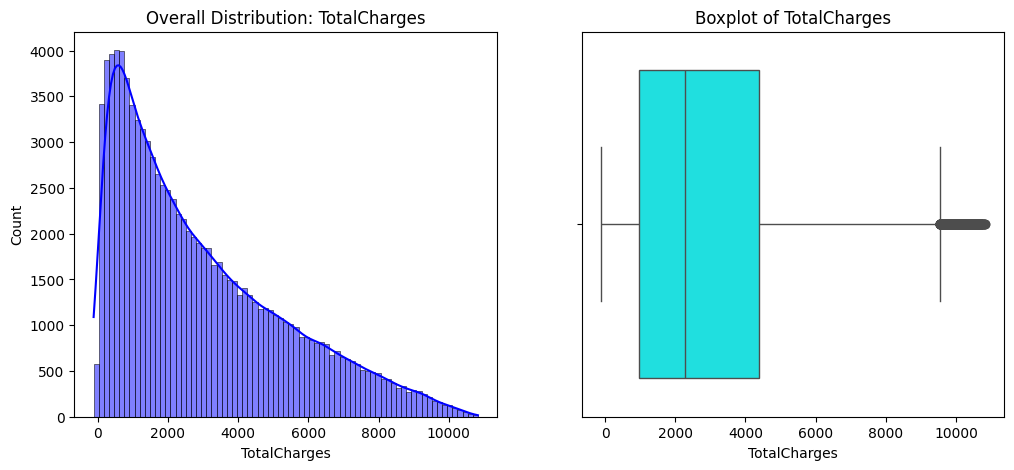

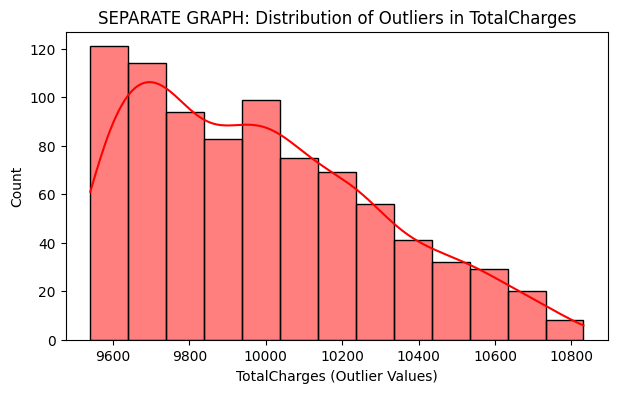

Applying Z-score analysis for TotalCharges...
Z-score method (|Z| > 3) found 288 extreme outliers in TotalCharges.



In [55]:
# 1. Outlier Detection using IQR
print("Outlier Detection (IQR Method)")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if len(outliers) > 0:
        print(f"Detected {len(outliers)} outliers in {col}")

        # Plot 1: Standard Boxplot and Histogram
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, color='blue')
        plt.title(f'Overall Distribution: {col}')

        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col], color='cyan')
        plt.title(f'Boxplot of {col}')
        plt.show()

        # Plot 2: Separate Graph for Outliers Only
        plt.figure(figsize=(7, 4))
        sns.histplot(outliers[col], kde=True, color='red')
        plt.title(f'SEPARATE GRAPH: Distribution of Outliers in {col}')
        plt.xlabel(f'{col} (Outlier Values)')
        plt.show()

        # 2. Apply Z-Score Detection (Recommended for identified outliers)
        print(f"Applying Z-score analysis for {col}...")
        z_scores = np.abs(stats.zscore(df[col]))
        z_outliers = df[z_scores > 3]
        print(f"Z-score method (|Z| > 3) found {len(z_outliers)} extreme outliers in {col}.\n")
    else:
        print(f"No outliers detected in {col}.\n")

5. VISUALIZATION METHOD:

A. BAR GRAPH:

/tmp/ipykernel_3799/390104029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Contract', data=df, palette='viridis', order=df['Contract'].value_counts().index)


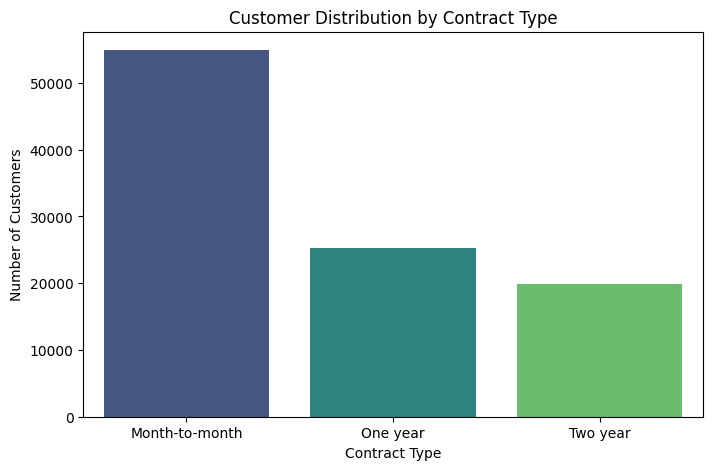

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Contract Types
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', data=df, palette='viridis', order=df['Contract'].value_counts().index)
plt.title('Customer Distribution by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

B. LINE CHART:

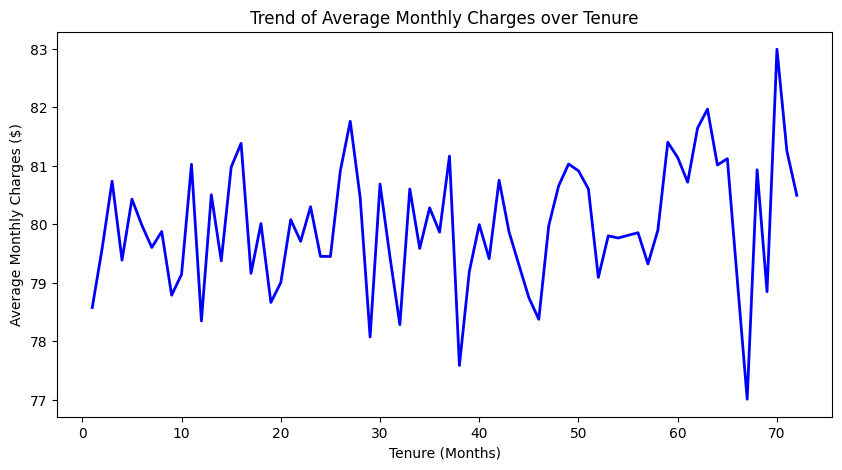

In [28]:
# Grouping by Tenure to calculate the average charge for each month
tenure_trend = df.groupby('Tenure')['MonthlyCharges'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x='Tenure', y='MonthlyCharges', data=tenure_trend, color='blue', linewidth=2)
plt.title('Trend of Average Monthly Charges over Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Average Monthly Charges ($)')
plt.show()

C. SCATTER PLOT:

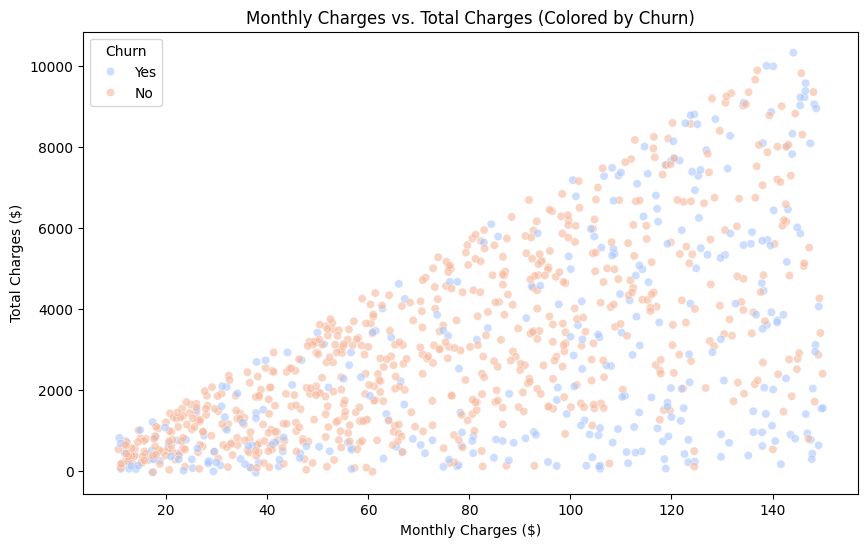

In [29]:
# We use a sample of 1000 points to make the plot readable
sample_df = df.sample(1000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', hue='Churn', data=sample_df, alpha=0.6, palette='coolwarm')
plt.title('Monthly Charges vs. Total Charges (Colored by Churn)')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Total Charges ($)')
plt.show()

D. BOX PLOT:

/tmp/ipykernel_3799/706123416.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set2')


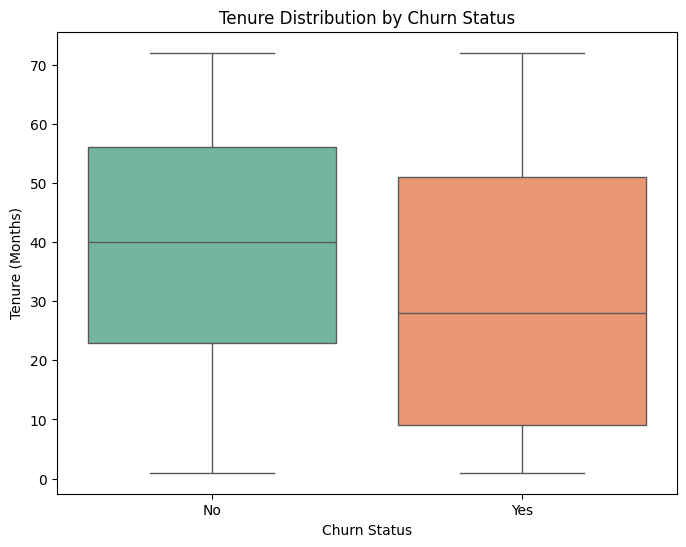

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Tenure', data=df, palette='Set2')
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn Status')
plt.ylabel('Tenure (Months)')
plt.show()

6. FEATURE ENGINEERING:

In [60]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load the dataset
df = pd.read_csv('synthetic_customer_churn_100k.csv')

# 2. Pre-processing & Feature Engineering
# Drop CustomerID as it has no predictive power
df = df.drop('CustomerID', axis=1)

# A. Label Encoding for the Target (Churn: Yes=1, No=0)
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# B. Ordinal Encoding for 'Contract' (Preserving the order of commitment)
contract_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_mapping)

# C. One-Hot Encoding for Nominal categories (Gender, PaymentMethod)
# drop_first=True prevents the "Dummy Variable Trap" (redundant columns)
df = pd.get_dummies(df, columns=['Gender', 'PaymentMethod'], drop_first=True)

# 3. Define Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 4. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling (Crucial for Logistic Regression performance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Apply Logistic Regression (The Requirement for Classification)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 7. Make Predictions
y_pred = model.predict(X_test_scaled)

# 8. Evaluation
print("MODEL SELECTION: LOGISTIC REGRESSION ")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix ")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report ")
print(classification_report(y_test, y_pred))

MODEL SELECTION: LOGISTIC REGRESSION 
Accuracy Score: 0.7234

Confusion Matrix 
[[11456  1838]
 [ 3694  3012]]

Classification Report 
              precision    recall  f1-score   support

           0       0.76      0.86      0.81     13294
           1       0.62      0.45      0.52      6706

    accuracy                           0.72     20000
   macro avg       0.69      0.66      0.66     20000
weighted avg       0.71      0.72      0.71     20000



7. R-SQUARED, MSE & MSA:

In [49]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# 1. Load data
df = pd.read_csv('synthetic_customer_churn_100k.csv')

# 2. Preprocess: Convert categories to numbers so the model can read them
le = LabelEncoder()
for col in ['Gender', 'Contract', 'PaymentMethod', 'Churn']:
    df[col] = le.fit_transform(df[col])

# 3. Define Task: Predicting 'TotalCharges' (Regression)
X = df.drop(['CustomerID', 'TotalCharges'], axis=1)
y = df['TotalCharges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Apply Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)

# 5. Apply All Metrics
r2  = r2_score(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
mae = mean_absolute_error(y_test, predictions) # This is your MSA

print(f"Regression Evaluation")
print(f"R-Squared: {r2:.4f} (Closer to 1 is better)")
print(f"MAE (MSA): {mae:.4f} (Average dollar error)")
print(f"MSE:       {mse:.4f} (Penalty for large errors)")

Regression Evaluation
R-Squared: 0.8763 (Closer to 1 is better)
MAE (MSA): 633.0846 (Average dollar error)
MSE:       705139.6598 (Penalty for large errors)


8. CONFUSION MATRIX

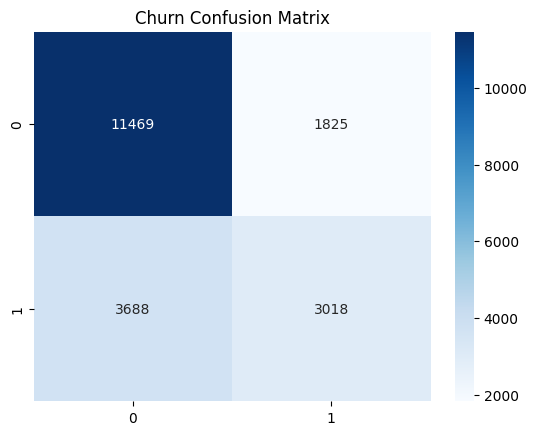

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Load and Preprocess
df = pd.read_csv('synthetic_customer_churn_100k.csv')
le = LabelEncoder()
for col in ['Gender', 'Contract', 'PaymentMethod', 'Churn']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['CustomerID', 'Churn'], axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train and Predict
model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
y_pred = model.predict(X_test)

# Draw Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Churn Confusion Matrix')
plt.show()

9. RANDOM FOREST BENCHMARK

 ML BENCHMARK: RANDOM FOREST 
Accuracy Score: 0.7319
True Positives (TP):  3361
False Positives (FP): 2018
True Negatives (TN):  11276
False Negatives (FN): 3345


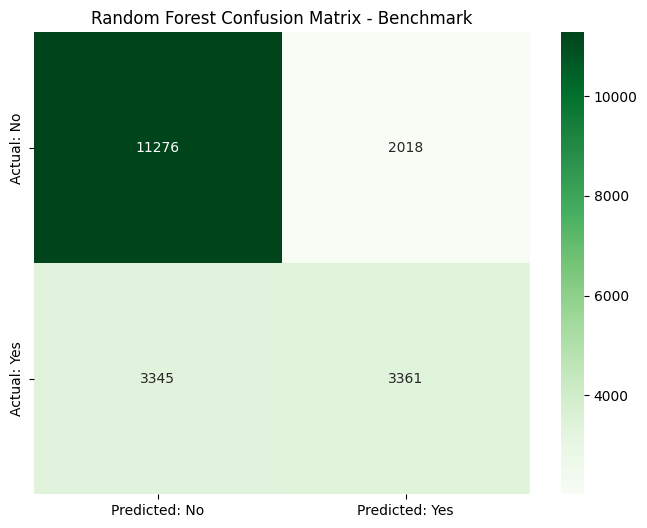

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
df = pd.read_csv('synthetic_customer_churn_100k.csv')

# 2. Preprocessing
df_ml = df.drop('CustomerID', axis=1)

# A. Label Encode the Target
le = LabelEncoder()
df_ml['Churn'] = le.fit_transform(df_ml['Churn'])

# B. Ordinal Encode 'Contract'
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_ml['Contract'] = df_ml['Contract'].map(contract_map)

# C. One-Hot Encode 'Gender' and 'PaymentMethod'
df_ml = pd.get_dummies(df_ml, columns=['Gender', 'PaymentMethod'], drop_first=True)

# 3. Define Features and Target
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# 4. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest Classifier
# n_estimators=100 means the model will build 100 individual trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 6. Testing (Predictions)
y_pred = rf_model.predict(X_test)

# 7. Evaluation & Benchmark Results
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(" ML BENCHMARK: RANDOM FOREST ")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"True Positives (TP):  {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN):  {tn}")
print(f"False Negatives (FN): {fn}")

# 8. Visualizing the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Random Forest Confusion Matrix - Benchmark')
plt.savefig('rf_confusion_matrix.png')